## Analysis of the Kraken OHLC Hourly Dataset
* entry count 25000
* starting: 2020-11-23 00:00:00+00
* ending: 2023-09-30 22:00:00+00
* horizon: 12
* focus on close price

In [1]:
import pandas as pd
import numpy as np
import holidays
import datetime
import seaborn as sns
from calendar import monthrange
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from keras.layers import LSTM, Dense, Dropout, BatchNormalization

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import RandomForestRegressor

from keras.models import load_model

2023-11-20 19:41:48.304404: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-20 19:41:48.304436: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-11-20 19:41:48.304471: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-11-20 19:41:48.433004: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
file_path = 'kraken_ohlc_hour.csv'
data = pd.read_csv(file_path)
data.head()

,bucket,open_price,high,low,close_price,volume
0,2023-09-29 21:00:00+00,1667.76,1669.03,1665.58,1665.78,315.937640
1,2023-09-29 20:00:00+00,1664.92,1670.67,1664.27,1667.27,243.705958
2,2023-09-29 19:00:00+00,1666.68,1667.18,1663.33,1664.97,438.050955
3,2023-09-29 18:00:00+00,1662.36,1667.32,1657.40,1666.68,1167.294457
4,2023-09-29 17:00:00+00,1666.59,1667.64,1662.24,1662.37,1383.290151


In [ ]:
data.tail()

## Data Cleaning and Preprocessing

In [2]:
def convert_timestamp(data): 
    data['bucket'] = pd.to_datetime(data['bucket'])
    data.sort_values('bucket', inplace=True)
    return data

def normalization_standard_scaler(data):
    scaler = StandardScaler()
    data[['open_price', 'high', 'low', 'close_price', 'volume']] = scaler.fit_transform(data[['open_price', 'high', 'low', 'close_price', 'volume']])
    return data

def add_feature_date(data):
    # time-based features
    data['hour'] = data['bucket'].dt.hour
    data['day_of_week'] = data['bucket'].dt.dayofweek  # Monday=0, Sunday=6
    data['day_of_month'] = data['bucket'].dt.day
    data['month'] = data['bucket'].dt.month
    data['year'] = data['bucket'].dt.year

    # binary feature for weekend
    data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x > 4 else 0)
    return data

def add_holiday_feature(data):
    us_holidays = holidays.UnitedStates()
    data['is_holiday'] = data['bucket'].apply(lambda x: x in us_holidays).astype(int)
    return data

def add_feature_high_low_range(data):
    data['hl_range'] = data['high'] - data['low']
    return data

def add_feature_lag(data, lags=[1]): 
    for lag in lags: 
        data['close_lag'+str(lag)] = data['close_price'].shift(lag)
    data = data.dropna() ## drop first few rows that are now NaN
    return data

In [ ]:
print("Checking for Nan values")
print(data.isnull().sum())

print("Description of Data")
print(data.describe())

In [ ]:
data = convert_timestamp(data)
data.head()

In [ ]:
data = normalization_standard_scaler(data)
data.head()

#### Adding date feature

In [ ]:
## converting datetime to features that can be used in model training
data = add_feature_date(data)
data.head()

#### Adding holidays

In [ ]:
# United States Holidays might have an impact?
data = add_holiday_feature(data)
data.head()

In [ ]:
# checking if holiday is set correctly
filter = data[(data['month'] == 12) & (data['day_of_month'] == 25)]
filter.head(1)

#### High and Low Range

In [ ]:
data = add_feature_high_low_range(data)
data.head()

#### Adding lagged feature of the close price

In [ ]:
data = add_feature_lag(data, lags=[1, 12, 168])
data.head()

#### Checking for correlation between features

In [ ]:
def plot_correlation_matrix(data): 
    plt.figure(figsize=(10, 8))  

    # Create correlation matrix
    corr = data.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    
    plt.show()


In [ ]:
plot_correlation_matrix(data)

1. High Correlation Between OHLC Prices: The Open, High, Low, and Close prices are highly correlated with each other, which is typical for financial data. This is expected as they represent the price of the same asset within the same period.

2. Volume Correlation: Volume seems to have a moderate positive correlation with the OHLC prices, which could indicate that higher trading volumes might be associated with higher price movements. This could be a useful feature for the prediction model.

3. Hour and Day of the Week: The hour of the day and the day of the week have some level of correlation with the target variable. These might capture intraday and weekly seasonal patterns in the data.

4. Close Lag Feature: The lagged closing price feature (close_lag1) shows a strong positive correlation with the current closing price. This is very common in time series data due to the autoregressive nature of financial time series. This feature is likely to be very useful for predictive modeling.

5. Weekend and Holiday Features: The is_weekend and is_holiday features have a lower correlation with the target variable. These features might not be directly correlated with the price but could still be important to include as they might capture irregular patterns in the data, such as lower trading volumes on weekends or holidays.

6. Multicollinearity: Given the high correlation between the OHLC features. It might be better to just  use the close price, because that is what will be predicted. 

7. High-Low Range: The hl_range feature has a lower correlation with the closing price compared to the OHLC prices and lagged features. This indicates that while it provides some unique information (potentially about intraday volatility), it may not be as strong a predictor as the lagged closing prices. However, it's still a valuable feature because it represents a different aspect of the data (volatility) that is not captured by just looking at the prices.

#### Feature Selection

##### Recursive Feature Elimination (RFE)

In [ ]:
# ranks the features importance
def perform_ref(data):
    data = data.copy()
    X = data.drop(['close_price', 'bucket'], axis=1)
    y = data['close_price']

    regressor = RandomForestRegressor(n_estimators=100, random_state=42)

    rfe = RFE(estimator=regressor, n_features_to_select=5, step=1)
    rfe.fit(X, y)

    features = pd.DataFrame({'Feature': X.columns, 'Importance': rfe.ranking_})
    print(features.sort_values(by='Importance'))

    selected_features = X[X.columns[rfe.support_]]
    
    print(f"Selected features: {selected_features}")

    return selected_features, y

In [ ]:
X_selected, y = perform_ref(data) # values used for linear regression

## Visualization

In [ ]:
def plot_close_price(data):
    plt.figure(figsize=(12, 6))
    plt.plot(data['bucket'], data['close_price'])
    plt.title('Hourly Closing Price (Standardized)')
    plt.xlabel('Time')
    plt.ylabel('Standardized Closing Price')
    plt.show()

In [ ]:
plot_close_price(data)

## Model Selection
Given the high correlation of the lagged closing price with the current closing price, time series models that take into account the autoregressive nature of the data are likely to perform well. Models you might consider include:

* ARIMA/SARIMA: These models are suitable for time series data with a trend or seasonal component.
* Machine Learning Models: Given the variety of features, a model like Gradient Boosting or Random Forest could capture complex patterns.
* Deep Learning Models: LSTM or GRU networks in deep learning can capture long-term dependencies in sequence data, which could be beneficial here.

Next Steps
* Simplifying the Feature Set: Given the high correlation between certain features, you may want to simplify your feature set to avoid multicollinearity issues.
* Baseline Model: Start with a simple model to establish a baseline performance. This could be a linear regression model using only the most correlated features.
* Complex Models: Move on to more complex models and compare their performance against the baseline.
* Cross-Validation: Use time series cross-validation methods to evaluate the performance of your models more robustly.
Hyperparameter Tuning: For machine learning and deep learning models, hyperparameter tuning is essential for maximizing model performance.

#### Linear Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


#### Random Forest 

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


#### ARIMA / SARIMA

For ARIMA, you need to specify the order (p, d, q) of the model:

* p is the number of autoregressive terms,
* d is the number of nonseasonal differences needed for stationarity,
* q is the number of lagged forecast errors in the prediction equation.


<span style="color:red">Not tested and data not prepared properly</span>.

In [ ]:
import statsmodels.api as sm

# Assuming you have a univariate time series 'y', which is your target variable
# Here, let's say we're considering a simple ARIMA(1,1,1) model

# Fit the ARIMA model
model = sm.tsa.ARIMA(y_train, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

y_pred = model_fit.forecast(steps=len(y_test))[0]

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


In [ ]:
model = sm.tsa.SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

#### LSTM

feature engineering helpers

In [7]:
## cyclic encoding for time based features
def encode_cyclic_feature(value, cycle_length, type):
    value_rad = (value / cycle_length) * 2 * np.pi
    if type == 'sin':
        return np.sin(value_rad) 
    else: 
        return np.cos(value_rad)

def normalize_feature(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value)

def get_distinct_count(data, column): 
    temp = data.copy()
    return len(pd.unique(temp[column]))

# returns the min and max value of the range
def get_min_max_value(data, column): 
    return data[column].min(), data[column].max()

def apply_cyclic_encoding(data, columms=['hour', 'day_of_week', 'month']): 
    for column in columms: 
        cycle_length = get_distinct_count(data, column)
        data[column + "_cos"] = data[column].apply(lambda x: encode_cyclic_feature(x, cycle_length, type='cos')).astype(float)
        data[column + "_sin"] = data[column].apply(lambda x: encode_cyclic_feature(x, cycle_length, type='sin')).astype(float)
    return data

def normalize_year(data, columns=['year']): 
    for column in columns: 
        min, max = get_min_max_value(data, column)
        data[column+'_normalized'] = data[column].apply(lambda x: normalize_feature(x, min, max+1)) # +1 to account for 2024
    return data

def get_month_length(month, year):
    return monthrange(year, month)[1]

# inspired by https://stats.stackexchange.com/questions/126230/optimal-construction-of-day-feature-in-neural-networks
def encode_day_of_month(day_of_month, month, year, type):
    normalized_day = (day_of_month - 1) / get_month_length(month, year)  # Subtract 1 to start from 0
    if type == 'sin': 
        return np.sin(2 * np.pi * normalized_day) 
    else: 
        return np.cos(2 * np.pi * normalized_day) 

def apply_day_of_month_encoding(data): 
    data["day_of_month_sin"] = data.apply(lambda row: encode_day_of_month(row['day_of_month'], row['month'], row['year'], 'sin'), axis=1)
    data["day_of_month_cos"] = data.apply(lambda row: encode_day_of_month(row['day_of_month'], row['month'], row['year'], 'cos'), axis=1)
    return data

def process_timestamp(data): 
    # fills in gaps in the dataset and creates 1 hour buckets
    data['bucket'] = pd.to_datetime(data['bucket'])
    data.set_index('bucket', inplace=True)
    data = data.resample('H').asfreq()
    data['close_price'] = data['close_price'].fillna(method='ffill') # carry over values from last hour 
    data['volume'] = data['volume'].fillna(0) # fill missing values with 0 because there have been no trades 
    data.sort_values('bucket', inplace=True)
    data.reset_index(inplace=True)
    return data

def apply_log_scaler(data, columns=['close_price', 'volume', 'close_lag12', 'close_lag168']): 
    for column in columns:
        data[column] = np.log1p(data[column])
    return data


In [8]:
# Data preperation
lstm_data = pd.read_csv(file_path)
#print(lstm_data)
lstm_data = lstm_data.drop(columns=['open_price', 'high', 'low'], axis=1)

lstm_data = process_timestamp(lstm_data)
lstm_data = add_feature_date(lstm_data)
lstm_data = add_feature_lag(lstm_data, lags=[12, 168])
lstm_data = add_holiday_feature(lstm_data)
lstm_data = apply_cyclic_encoding(lstm_data)
lstm_data = apply_day_of_month_encoding(lstm_data)
lstm_data = normalize_year(lstm_data) # has to be updated yearly 
lstm_data = apply_log_scaler(lstm_data)

lstm_data = lstm_data.drop(columns=['bucket','hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)

lstm_data.head()

#cycle_length = get_distinct_count(data, 'hour')
#lstm_data['hour_sin'] = lstm_data['hour'].apply(lambda x: encode_cyclic_feature(x, cycle_length)).astype(float)

,close_price,volume,is_weekend,close_lag12,close_lag168,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
168,1.099205,3.931159,0,1.085189,1.386294,0,-8.660254e-01,-0.500000,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
169,1.099205,0.000000,0,1.071584,1.386294,0,-7.071068e-01,-0.707107,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
170,1.073096,2.638756,0,1.071584,1.386294,0,-5.000000e-01,-0.866025,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
171,1.033184,5.380558,0,1.071584,1.386297,0,-2.588190e-01,-0.965926,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
172,1.057790,5.303305,0,1.071584,1.386297,0,-1.836970e-16,-1.000000,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0


In [58]:
lstm_data.tail()

,bucket,close_price,volume,is_weekend,close_lag12,close_lag168,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
71403,2023-09-29 17:00:00+00:00,7.416601,7.232943,0,7.412643,7.373286,0,-2.588190e-01,-0.965926,-0.900969,-0.433884,-1.836970e-16,-1.0,-0.406737,0.913545,0.888889
71404,2023-09-29 18:00:00+00:00,7.419189,7.063300,0,7.414615,7.374761,0,-1.836970e-16,-1.000000,-0.900969,-0.433884,-1.836970e-16,-1.0,-0.406737,0.913545,0.888889
71405,2023-09-29 19:00:00+00:00,7.418163,6.084615,0,7.430500,7.373462,0,2.588190e-01,-0.965926,-0.900969,-0.433884,-1.836970e-16,-1.0,-0.406737,0.913545,0.888889
71406,2023-09-29 20:00:00+00:00,7.419542,5.500057,0,7.422200,7.373073,0,5.000000e-01,-0.866025,-0.900969,-0.433884,-1.836970e-16,-1.0,-0.406737,0.913545,0.888889
71407,2023-09-29 21:00:00+00:00,7.418649,5.758705,0,7.422912,7.374610,0,7.071068e-01,-0.707107,-0.900969,-0.433884,-1.836970e-16,-1.0,-0.406737,0.913545,0.888889


In [20]:
def create_sequences_np(data, features, lookback):
    data_array = data[features].to_numpy()
    X, y = [], []
    for i in range(lookback, len(data_array)):
        X.append(data_array[i-lookback:i])
        y.append(data_array[i, data.columns.get_loc('close_price')])
    return np.array(X), np.array(y)

features = ['close_price', 'volume', 'is_weekend', 'close_lag12', 'close_lag168', 
            'is_holiday', 'hour_cos', 'hour_sin', 'day_of_week_cos', 
            'day_of_week_sin', 'month_cos', 'month_sin', 
            'day_of_month_sin', 'day_of_month_cos', 'year_normalized']

lookback = 1
X, y = create_sequences_np(lstm_data, features, lookback)

In [21]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

n_features = len(features)  # Number of features used

# LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(lookback, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# split point at 20 percent 
split_idx = int(len(X) * 0.8)

# validation set with the last 20 percent of the dataset 
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# maybe 43 epochs seems to have a good loss 
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100
1781/1781 [==============================] - 10s 5ms/step - loss: 0.8729 - val_loss: 0.0185
Epoch 2/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.2194 - val_loss: 0.0377
Epoch 3/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.1799 - val_loss: 0.0134
Epoch 4/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.1525 - val_loss: 0.0539
Epoch 5/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.1320 - val_loss: 0.0065
Epoch 6/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.1140 - val_loss: 0.0890
Epoch 7/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.1005 - val_loss: 0.0068
Epoch 8/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.0889 - val_loss: 0.0084
Epoch 9/100
1781/1781 [==============================] - 7s 4ms/step - loss: 0.0792 - val_loss: 0.0080
Epoch 10/100
1781/1781 [==============================] - 7s 4ms/step - 

446/446 [==============================] - 1s 2ms/step


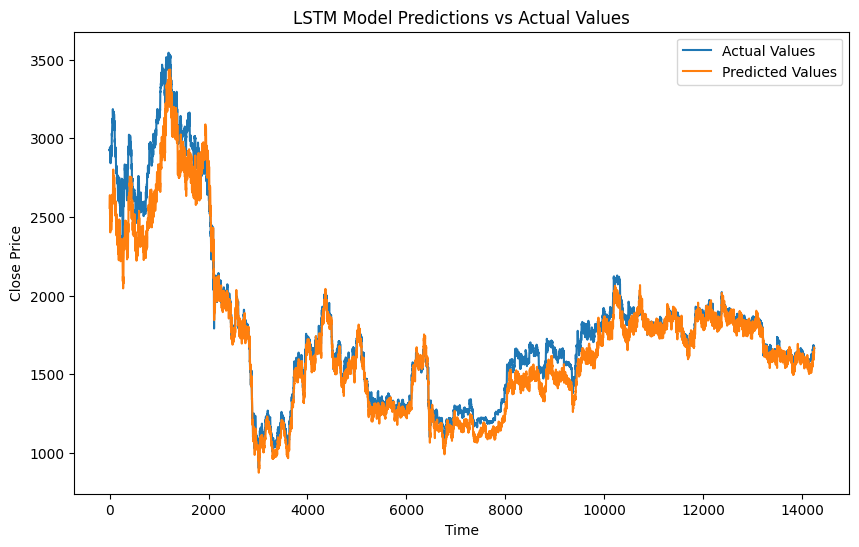

In [16]:
## Plotting the validation set 
y_pred = model.predict(X_val)

y_val_true = np.expm1(y_val)
y_pred_true = np.expm1(y_pred)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_val_true, label='Actual Values')
plt.plot(y_pred_true, label='Predicted Values')
plt.title('LSTM Model Predictions vs Actual Values')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [22]:
## load non-training data: + 12hour lookback 

# Data preperation
test_lstm = pd.read_csv('test_data.csv')
original_lstm_test = test_lstm.copy()
#print(lstm_data)
test_lstm = test_lstm.drop(columns=['open_price', 'high', 'low'], axis=1)

test_lstm = process_timestamp(test_lstm)
test_lstm = add_feature_date(test_lstm)
test_lstm = add_feature_lag(test_lstm, lags=[12, 168])
test_lstm = add_holiday_feature(test_lstm)
test_lstm = apply_cyclic_encoding(test_lstm)
test_lstm = apply_day_of_month_encoding(test_lstm)
test_lstm = normalize_year(test_lstm) # has to be updated yearly 
test_lstm = apply_log_scaler(test_lstm)

test_lstm = test_lstm.drop(columns=['hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)

test_lstm.head()

,bucket,close_price,volume,is_weekend,close_lag12,close_lag168,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
168,2023-09-29 10:00:00+00:00,7.37461,0.0,0,7.37461,7.374240,0,-0.866025,5.000000e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
169,2023-09-29 11:00:00+00:00,7.37461,0.0,0,7.37461,7.376458,0,-0.965926,2.588190e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
170,2023-09-29 12:00:00+00:00,7.37461,0.0,0,7.37461,7.375381,0,-1.000000,1.224647e-16,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
171,2023-09-29 13:00:00+00:00,7.37461,0.0,0,7.37461,7.375788,0,-0.965926,-2.588190e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
172,2023-09-29 14:00:00+00:00,7.37461,0.0,0,7.37461,7.377590,0,-0.866025,-5.000000e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0


In [23]:
test_lstm.tail()

,bucket,close_price,volume,is_weekend,close_lag12,close_lag168,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
200,2023-09-30 18:00:00+00:00,7.425376,5.073876,1,7.422900,7.37461,0,-1.836970e-16,-1.000000,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
201,2023-09-30 19:00:00+00:00,7.426900,4.975117,1,7.422523,7.37461,0,2.588190e-01,-0.965926,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
202,2023-09-30 20:00:00+00:00,7.427352,4.186400,1,7.424058,7.37461,0,5.000000e-01,-0.866025,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
203,2023-09-30 21:00:00+00:00,7.423992,5.975280,1,7.424374,7.37461,0,7.071068e-01,-0.707107,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
204,2023-09-30 22:00:00+00:00,7.424303,4.573863,1,7.424768,7.37461,0,8.660254e-01,-0.500000,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0


1/1 [==============================] - 0s 14ms/step


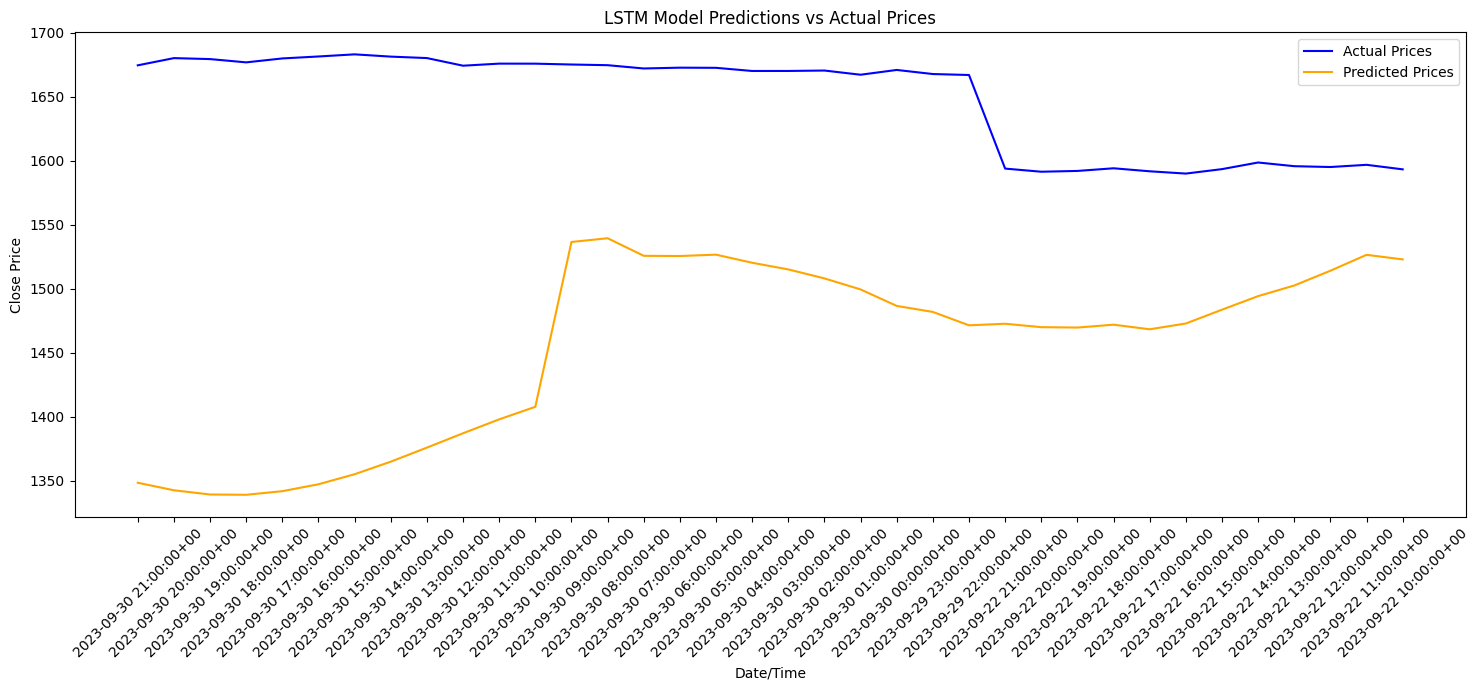

In [24]:
# Extract features from the test data
features = ['close_price', 'volume', 'is_weekend', 'close_lag12', 'close_lag168',
            'is_holiday', 'hour_cos', 'hour_sin', 'day_of_week_cos',
            'day_of_week_sin', 'month_cos', 'month_sin',
            'day_of_month_sin', 'day_of_month_cos', 'year_normalized']

# Prepare the test data in the same way as the training data was prepared
# ...

# Start the loop to predict each next hour and collect the actual and predicted prices
predicted_prices = []
actual_prices = original_lstm_test['close_price'].values[lookback:]  # actual prices without log transformation
timestamps = original_lstm_test['bucket'].values[lookback:]  # corresponding timestamps

for i in range(lookback, len(test_lstm)):
    last_sequence = test_lstm.iloc[i-lookback:i][features].values.reshape((1, lookback, len(features)))
    predicted_log_price = model.predict(last_sequence)
    predicted_price = np.expm1(predicted_log_price)[0, 0]  # inverse log transformation
    predicted_prices.append(predicted_price)

# Convert predictions to a numpy array
predicted_prices = np.array(predicted_prices)

# Plotting the results
plt.figure(figsize=(15, 7))
plt.plot(timestamps, actual_prices, label='Actual Prices', color='blue')
plt.plot(timestamps, predicted_prices, label='Predicted Prices', color='orange')
plt.xlabel('Date/Time')
plt.ylabel('Close Price')
plt.title('LSTM Model Predictions vs Actual Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()


#### Example of the day_of_month encoding

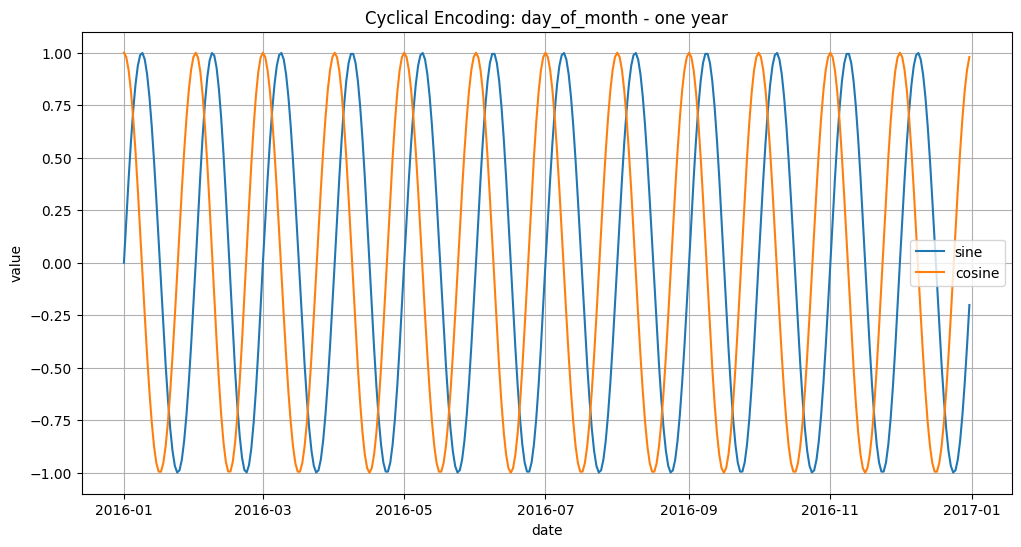

In [10]:
year = 2016
data = pd.DataFrame({'date': pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')})
data['month'] = data['date'].dt.month
data['day_of_month'] = data['date'].dt.day
data['year'] = data['date'].dt.year

data['day_sin'], data['day_cos'] = zip(*data.apply(lambda row: encode_day_of_month(row['day_of_month'], row['month'], row['year']), axis=1))

plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['day_sin'], label='sine')
plt.plot(data['date'], data['day_cos'], label='cosine')
plt.xlabel('date')
plt.ylabel('value')
plt.title('Cyclical Encoding: day_of_month - one year')
plt.legend()
plt.grid(True)
plt.show()

# OUTDATE STUFF BELOW UNTIL SKFORECAST

In [13]:
data

,date,month,day_of_month,year,day_sin,day_cos
0,2016-01-01,1,1,2016,0.000000,1.000000
1,2016-01-02,1,2,2016,0.201299,0.979530
2,2016-01-03,1,3,2016,0.394356,0.918958
3,2016-01-04,1,4,2016,0.571268,0.820763
4,2016-01-05,1,5,2016,0.724793,0.688967
...,...,...,...,...,...,...
361,2016-12-27,12,27,2016,-0.848644,0.528964
362,2016-12-28,12,28,2016,-0.724793,0.688967
363,2016-12-29,12,29,2016,-0.571268,0.820763
364,2016-12-30,12,30,2016,-0.394356,0.918958


In [261]:
lstm_data.tail()

,bucket,close_price,volume,hour,day_of_week,day_of_month,month,year,is_weekend,close_lag1,close_lag12,close_lag168,is_holiday,hour_cos,day_of_week_cos,day_of_month_cos,month_cos,year_normalized
4,2023-09-29 17:00:00+00:00,1662.37,1383.290151,17,4,29,9,2023,0,1666.62,1655.80,1591.86,0,-2.588190e-01,-0.900969,0.918958,-1.836970e-16,0.888889
3,2023-09-29 18:00:00+00:00,1666.68,1167.294457,18,4,29,9,2023,0,1662.37,1659.07,1594.21,0,-1.836970e-16,-0.900969,0.918958,-1.836970e-16,0.888889
2,2023-09-29 19:00:00+00:00,1664.97,438.050955,19,4,29,9,2023,0,1666.68,1685.65,1592.14,0,2.588190e-01,-0.900969,0.918958,-1.836970e-16,0.888889
1,2023-09-29 20:00:00+00:00,1667.27,243.705958,20,4,29,9,2023,0,1664.97,1671.71,1591.52,0,5.000000e-01,-0.900969,0.918958,-1.836970e-16,0.888889
0,2023-09-29 21:00:00+00:00,1665.78,315.937640,21,4,29,9,2023,0,1667.27,1672.90,1593.97,0,7.071068e-01,-0.900969,0.918958,-1.836970e-16,0.888889


Thoughts about the feature set: 

What should be the input for a prediction?
Things that definitely need to be an input  
* timestamp (hour, day_of_week, day_of_month, month, year)
* Maybe as addition: is_weekend, is_holiday

Things that are not known when predicting a timestamp in the future: 
* open_price
* high
* low
* close_price 
* close_lag1 would be known if only predicting one hour into the feature
* close_lag12 is similar to close_lag1 but instead of 1 hour it is 12 hours

How could the close price be predicted? 

Maybe it also makes sense to count the trades made for each hour indicator of how much is going on

GPT
Predicting the close price of a financial asset using LSTM (Long Short-Term Memory) networks is a common task in time series analysis and forecasting. Given the features you have and the limitations you've identified, here’s how you could approach setting up an LSTM model:

1. Feature Selection and Engineering
Firstly, let's decide on the features to use:

* Timestamp-Related Features: Include hour, day_of_week, day_of_month, month, and year as these provide temporal context. Encoding them appropriately is crucial.
* Additional Features: is_weekend and is_holiday can be useful as binary flags indicating special days.
* Lagged Features: close_lag1 and close_lag12 can be used. These represent historical closing prices which are often predictive in time series forecasting.
* Excluding Features: Features like open_price, high, low, and close_price won't be available for future timestamps. However, if you're predicting just one hour ahead, close_lag1 will essentially be the current close_price.

2. Data Preprocessing
Normalization: Financial time series data should be normalized or standardized for effective training of neural networks.
Sequence Creation: Transform the data into sequences that the LSTM can process. Each sequence would be a series of data points leading up to the time you want to predict.

3. LSTM Model Design
Input Layer: The shape of the input layer should match the number of features used.
LSTM Layers: Start with one or two LSTM layers with a moderate number of neurons. You can experiment with more layers or neurons.
Dropout Layers: To prevent overfitting, consider adding dropout layers.
Output Layer: The output layer should have one neuron, as you're predicting a single value (close_price).
Loss Function: Use a regression loss function like Mean Squared Error (MSE).
Optimizer: Common choices are Adam or RMSprop.

4. Training and Validation
Splitting Data: Divide your dataset into training, validation, and test sets.
Batch Size and Epochs: Choose appropriate batch size and number of epochs. Start with a smaller number and increase based on performance.

5. Evaluation and Tuning
Evaluate Performance: Use metrics like MSE or MAE (Mean Absolute Error) on the test set to evaluate the model.
Hyperparameter Tuning: Adjust the number of layers, neurons, learning rate, etc., to improve performance.


Points to Consider
* Model Complexity: Financial time series can be highly non-linear and noisy. Start with a simpler model and gradually increase complexity.
* Feature Importance: Experiment with different sets of features to see what works best.
Lookback Period: The length of the input sequences (lookback period) is crucial. Experiment with different lengths.
* Overfitting: Watch out for overfitting. Regularization techniques like dropout or early stopping can be helpful.

Remember, financial markets are influenced by a myriad of factors, and it's challenging to capture all these influences in a model. Always be cautious and validate your model thoroughly.







In [262]:
def get_train_test_data(data, traning_size=0.8): 
    train_size = int(len(data) * traning_size)

    # splitting data
    train_data = data[:train_size]
    test_data = data[train_size:]

    # features and target for training and test sets
    X_train = train_data.drop(['bucket', 'close_price'], axis=1)
    y_train = train_data['close_price']
    X_test = test_data.drop(['bucket', 'close_price'], axis=1)
    y_test = test_data['close_price']

    return X_train, y_train, X_test, y_test

In [263]:
X_train, y_train, X_test, y_test = get_train_test_data(lstm_data)
print(X_train.shape)
print(X_test.shape)

(54212, 16)
(13553, 16)


In [264]:
#columns_to_keep = ['bucket', 'close_price', 'volume', 'close_lag1', 'close_lag12', 'close_lag168']
#lstm_data = lstm_data.loc[:, columns_to_keep]
#lstm_data.tail()

Maybe try out the following things

Data Preprocessing:

Ensure that your data is preprocessed correctly, including data scaling, handling missing values, and feature engineering if necessary.
Train-Test Split:

Split your dataset into training and validation/testing sets to evaluate model performance. Common splits are 80/20 or 70/30.
Sequence Length:

Determine the appropriate sequence length for your data. Longer sequences may capture more context but require more memory and training time. Shorter sequences may lose important information.
Batch Size:

Experiment with different batch sizes. Smaller batches can provide more frequent weight updates but may require more training steps.
Number of LSTM Layers:

Decide how many LSTM layers to use. Deeper networks can capture more complex patterns but might require more data and longer training times. Starting with one or two layers is common.
Number of LSTM Units:

You can experiment with increasing the number of LSTM units in each layer to make the model more expressive. However, adding too many units may lead to overfitting if your dataset is small.
Dropout:

Use dropout regularization to prevent overfitting. Experiment with different dropout rates (e.g., 0.2, 0.5) on LSTM layers and the final fully connected layers.
Learning Rate:

Adjust the learning rate. A learning rate that is too high may lead to overshooting, while a learning rate that is too low may result in slow convergence. Learning rate schedulers can also help.
Optimizer:

Experiment with different optimizers (e.g., Adam, RMSprop, SGD) to see which one works best for your problem.
Number of Epochs:

Train your model for an appropriate number of epochs. Use early stopping to prevent overfitting and save the best model based on validation performance.
Model Architecture:

Depending on your problem, you can consider variations of LSTM, such as Bidirectional LSTM, stacked LSTM layers, or combining LSTM with other types of layers like Convolutional layers.
Hyperparameter Search:

Perform a hyperparameter search using techniques like grid search or random search to find the best combination of hyperparameters for your specific problem.
Evaluation Metrics:

Choose appropriate evaluation metrics for your task (e.g., accuracy, mean squared error, F1-score) and monitor them during training.
Regularization:

Besides dropout, consider other regularization techniques like L1 or L2 regularization if needed.
Data Augmentation:

For small datasets, data augmentation techniques like adding noise or jitter to input sequences can help improve generalization.
Model Complexity:

Keep in mind that adding more LSTM units and layers increases model complexity, which may require more data to generalize well. Be cautious about overfitting.
Hardware and Computational Resources:

Consider the available hardware (CPU/GPU) and computational resources when designing your model, especially if you plan to train larger networks.


In [265]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# make sure the dataset is not scaled with StandardScaler before
X_train, y_train, X_test, y_test = get_train_test_data(lstm_data)

# scaling data
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# reshaping data for LSTM
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Create the Sequential model
model = Sequential()

# Add the first LSTM layer with more units, batch normalization, and dropout
model.add(LSTM(32, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32, return_sequences=True))
model.add(LSTM(7, return_sequences=True)) # number of features
model.add(Dense(1))
# Compile the model with appropriate loss and optimizer
model.compile(loss='mean_squared_error', optimizer='rmsprop')

model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=2)

y_pred_scaled = model.predict(X_test_scaled)

# dummy array with zeros to get the same shape as test data
dummy_array = np.zeros(shape=(len(y_pred_scaled), X_test_scaled.shape[2]))
# Replace y_pred_scaled into the first column of the dummy array
dummy_array[:, 0] = y_pred_scaled.ravel()  # flatten

print(dummy_array.shape)

y_pred = scaler.inverse_transform(dummy_array)  
y_pred = y_pred[:, 0]

print(y_pred)

y_test = y_test.ravel()

print(y_test.shape)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

In [ ]:
test_data = pd.read_csv('test_data.csv')

test_data['bucket'] = pd.to_datetime(test_data['bucket'])

X_test_true = test_data.drop(['bucket', 'close_price'], axis=1)
y_test_true = test_data['close_price']

# scaling the test data (only transform not fitting the scaler again)
X_test_true_scaled = scaler.transform(X_test)

print(X_test_true_scaled)

# reshaping for LSTM 
X_test_true_scaled = X_test_true_scaled.reshape((X_test_true_scaled.shape[0], 1, X_test_true_scaled.shape[1]))

predicted_test_scaled = model.predict(X_test_scaled)

# dummy array with zeros (same shape as test data)
dummy_array = np.zeros(shape=(len(predicted_test_scaled), X_test_true_scaled.shape[2]))

# placing the predictions in the appropriate column of this dummy array
dummy_array[:, 0] = predicted_test_scaled.ravel()  # flatten

# inverse transform using the dummy array (shape has to be the same)
predicted_test = scaler.inverse_transform(dummy_array)

# Extract the predictions for the close_price (first column)
predicted_test = predicted_test[:, 0]

# slice the predictions to match the length of test_data
predicted_test_sliced = predicted_test[:len(test_data['bucket'])]

plt.figure(figsize=(12, 6))
plt.plot(test_data['bucket'], y_test_true, label='True Values')
plt.plot(test_data['bucket'], predicted_test_sliced, label='Predictions')
plt.title('LSTM Predictions vs True Values')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

Graph shows very poor performance

Maybe have a look at: 
https://www.kaggle.com/code/amarsharma768/stock-price-prediction-using-lstm/notebook
https://stackoverflow.com/questions/50054419/extremely-poor-prediction-lstm-time-series

In [ ]:
### saving the lstm model
# HDF5 file
model.save('lstm_ethusd_model.h5')


In [ ]:
### load the model 
model = load_model('lstm_ethusd_model.h5')

### predicting 

In [ ]:
#  preprocessed new data in the same way as training/test data
new_data_processed = scaler.transform(new_data)
new_data_processed = new_data_processed.reshape((new_data_processed.shape[0], 1, new_data_processed.shape[1]))

new_predictions_scaled = model.predict(new_data_processed)

new_predictions = scaler.inverse_transform(new_predictions_scaled)[:, 0]  # 'close_price' has to be at index 0


In [ ]:
import joblib
# Save the scaler
joblib.dump(scaler, 'my_scaler.gz')
# Load it 
scaler = joblib.load('my_scaler.gz')


### skforecast 

https://joaquinamatrodrigo.github.io/skforecast/0.11.0/introduction-forecasting/introduction-forecasting.html

In [ ]:
def add_holiday_feature_custom(data):
    us_holidays = holidays.UnitedStates()
    data['is_holiday'] = data.index.to_series().apply(lambda x: x.date() in us_holidays).astype(int)
    return data


In [ ]:
forecast_data = pd.read_csv(file_path)

forecast_data['bucket'] = pd.to_datetime(forecast_data['bucket'], format='%Y-%m-%d %H')
forecast_data = forecast_data.set_index('bucket')

forecast_data = forecast_data.resample('H').ffill()

forecast_data = add_feature_lag(forecast_data, lags=[1, 12, 168])
forecast_data = add_feature_high_low_range(forecast_data) 
forecast_data = add_holiday_feature_custom(forecast_data)

forecast_data = forecast_data.rename(columns={'close_price':'y'})

print(forecast_data.head())



forecast_data = forecast_data.sort_index()

forecast_data.head()

In [ ]:
forecast_data.head()

In [ ]:
ts = pd.Series(forecast_data['y'].values, index=forecast_data.index)
ts

In [ ]:
import pandas as pd
from skforecast.ForecasterAutoreg import ForecasterAutoreg
from sklearn.ensemble import RandomForestRegressor

forecaster = ForecasterAutoreg(regressor = RandomForestRegressor(random_state=123), lags = 12)
forecaster.fit(y=ts)
forecaster

In [ ]:
prediction = pd.DataFrame(forecaster.predict(steps=12))
prediction.reset_index(names=['time'])
prediction.columns

In [ ]:
true = pd.read_csv(file_path)

start_date = pd.to_datetime('2023-09-22 22:00:00+00:00')
end_date = pd.to_datetime('2023-09-23 09:00:00+00:00')

columns_to_keep = ['bucket', 'close_price']
true = true.drop(columns=[col for col in true.columns if col not in columns_to_keep])

true['bucket'] = pd.to_datetime(true['bucket'])

true = true[(true['bucket'] >= start_date) & (true['bucket'] <= end_date)]

true

In [ ]:
merged_df = prediction.merge(true, left_index=True, right_on='bucket', how='inner')
merged_df['error'] = merged_df['pred'] - merged_df['close_price']
merged_df['relative_error'] = (abs(merged_df['pred'] - merged_df['close_price']) / abs(merged_df['close_price'])) * 100
merged_df